PHASE 2

In [678]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns 
import numpy as np

In [679]:
housing1 = [pd.read_csv(f"CA_SALES/CA-{i:0>2}.csv") for i in range(1,4)]

In [680]:
housing1 = pd.concat(housing1)
housing1 # MADE IT A DATAFRAME


,SALE TYPE,SOLD DATE,PROPERTY TYPE,ADDRESS,CITY,STATE OR PROVINCE,ZIP OR POSTAL CODE,PRICE,BEDS,BATHS,...,STATUS,NEXT OPEN HOUSE START TIME,NEXT OPEN HOUSE END TIME,URL (SEE https://www.redfin.com/buy-a-home/comparative-market-analysis FOR INFO ON PRICING),SOURCE,MLS#,FAVORITE,INTERESTED,LATITUDE,LONGITUDE
0,MLS Listing,NaN,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293.0,495000,1.0,1.0,...,Active,August-2-2025 01:00 PM,August-2-2025 04:00 PM,https://www.redfin.com/CA/Playa-del-Rey/7740-R...,CRMLS,SB25171301,N,Y,33.958446,-118.431165
1,MLS Listing,NaN,Condo/Co-op,100 S Alameda St #341,Los Angeles,CA,90012.0,575000,1.0,1.0,...,Active,August-2-2025 01:00 PM,August-2-2025 04:00 PM,https://www.redfin.com/CA/Los-Angeles/100-S-Al...,CRMLS,BB25167303,N,Y,34.048017,-118.237750
2,MLS Listing,NaN,Single Family Residential,20142 Allentown Dr,Woodland Hills,CA,91364.0,1890000,4.0,3.0,...,Active,August-2-2025 11:00 AM,August-2-2025 02:00 PM,https://www.redfin.com/CA/Woodland-Hills/20142...,CRMLS,SR25169661,N,Y,34.162213,-118.572562
3,MLS Listing,NaN,Multi-Family (2-4 Unit),115-119 W Avenue 43,Los Angeles,CA,90065.0,1469000,5.0,3.5,...,Active,August-3-2025 01:00 PM,August-3-2025 03:00 PM,https://www.redfin.com/CA/Los-Angeles/115-W-Av...,CRMLS,PF25169262,N,Y,34.094964,-118.209053
4,MLS Listing,NaN,Townhouse,3450 Cahuenga Blvd W #905,Los Angeles,CA,90068.0,1000000,2.0,2.5,...,Active,NaN,NaN,https://www.redfin.com/CA/Los-Angeles/3450-Cah...,CRMLS,SR25169718,N,Y,34.132737,-118.353523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,MLS Listing,NaN,Vacant Land,0 Helen Way,Los Gatos,CA,95033.0,249000,NaN,NaN,...,Active,NaN,NaN,https://www.redfin.com/CA/Los-Gatos/Helen-Way-...,MLSListings,ML81912636,N,Y,37.154438,-121.987605
175,MLS Listing,NaN,Vacant Land,21578 Alma Ct,Los Gatos,CA,95033.0,375000,NaN,NaN,...,Active,NaN,NaN,https://www.redfin.com/CA/Los-Gatos/21578-Alma...,MLSListings,ML81912559,N,Y,37.153709,-121.984504
176,MLS Listing,NaN,Vacant Land,21745 Lindbergh Dr,Los Gatos,CA,95033.0,19999,NaN,NaN,...,Active,NaN,NaN,https://www.redfin.com/CA/Los-Gatos/21745-lind...,MLSListings,ML81912347,N,Y,37.149426,-121.991343
177,MLS Listing,NaN,Vacant Land,21741 Lindbergh Dr,Los Gatos,CA,95033.0,49950,NaN,NaN,...,Active,NaN,NaN,https://www.redfin.com/CA/Los-Gatos/21741-lind...,MLSListings,ML81911847,N,Y,37.149555,-121.991289


In [681]:
housing1.info()

<class 'pandas.DataFrame'>
Index: 879 entries, 0 to 178
Data columns (total 27 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   SALE TYPE                                                                                    879 non-null    str    
 1   SOLD DATE                                                                                    0 non-null      float64
 2   PROPERTY TYPE                                                                                879 non-null    str    
 3   ADDRESS                                                                                      879 non-null    str    
 4   CITY                                                                                         877 non-null    str    
 5   STATE OR PROVINCE                                   

In [682]:
housing1.isna().sum() #GOING TO DROP COLUMNS

SALE TYPE                                                                                        0
SOLD DATE                                                                                      879
PROPERTY TYPE                                                                                    0
ADDRESS                                                                                          0
CITY                                                                                             2
STATE OR PROVINCE                                                                                0
ZIP OR POSTAL CODE                                                                               1
PRICE                                                                                            0
BEDS                                                                                            56
BATHS                                                                                           74
LOCATION  

In [683]:
housing1 = housing1.drop(columns=["SOLD DATE", "HOA/MONTH", "NEXT OPEN HOUSE START TIME", "NEXT OPEN HOUSE END TIME"])

In [684]:
housing1.isna().sum()

SALE TYPE                                                                                       0
PROPERTY TYPE                                                                                   0
ADDRESS                                                                                         0
CITY                                                                                            2
STATE OR PROVINCE                                                                               0
ZIP OR POSTAL CODE                                                                              1
PRICE                                                                                           0
BEDS                                                                                           56
BATHS                                                                                          74
LOCATION                                                                                        2
SQUARE FEET         

In [685]:
income = pd.read_csv("INCOME.csv")
school = pd.read_csv("pubschls.csv")
school.info()
school[school['Zip'] == 90001]

<class 'pandas.DataFrame'>
RangeIndex: 18387 entries, 0 to 18386
Data columns (total 46 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CDSCode               18387 non-null  object 
 1   NCESDist              18387 non-null  str    
 2   NCESSchool            18386 non-null  str    
 3   StatusType            18386 non-null  str    
 4   County                18386 non-null  str    
 5   District              18386 non-null  str    
 6   School                18386 non-null  str    
 7   Street                18386 non-null  str    
 8   StreetAbr             18386 non-null  str    
 9   City                  18386 non-null  str    
 10  Zip                   18386 non-null  str    
 11  State                 18386 non-null  str    
 12  MailStreet            18386 non-null  str    
 13  MailStrAbr            18386 non-null  str    
 14  MailCity              18386 non-null  str    
 15  MailZip               18386 no

C:\Users\dilpi\AppData\Local\Temp\ipykernel_23184\1831226704.py:2: DtypeWarning: Columns (0: CDSCode) have mixed types. Specify dtype option on import or set low_memory=False.
  school = pd.read_csv("pubschls.csv")


,CDSCode,NCESDist,NCESSchool,StatusType,County,District,School,Street,StreetAbr,City,...,Virtual,Magnet,YearRoundYN,FederalDFCDistrictID,Latitude,Longitude,AdmFName,AdmLName,LastUpDate,Multilingual


In [686]:
income.info()
income['ZipCode']

<class 'pandas.DataFrame'>
RangeIndex: 75355 entries, 0 to 75354
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TaxYear            75355 non-null  int64  
 1   ZipCode            75355 non-null  str    
 2   State              75355 non-null  str    
 3   City               75351 non-null  str    
 4   County             75351 non-null  str    
 5   Returns            75355 non-null  int64  
 6   CAAGI              75355 non-null  int64  
 7   TotalTaxLiability  75355 non-null  int64  
 8   CountyLatitude     75287 non-null  float64
 9   CountyLongitude    75287 non-null  float64
 10  GeoCounty          75287 non-null  str    
 11  GeoCity            75114 non-null  str    
 12  GeoZipCode         75000 non-null  str    
dtypes: float64(2), int64(4), str(7)
memory usage: 7.5 MB


0               90001
1               90002
2               90003
3               90004
4               90005
             ...     
75350           96160
75351           96161
75352           96162
75353     Suppressed1
75354    Unallocated2
Name: ZipCode, Length: 75355, dtype: str

In [687]:
#Going to merge on Zip as both have it. Will rename to zip to match 2/3 dataframe
income = income.rename(columns={'ZipCode': 'Zip'})
housing1 = housing1.rename(columns={"ZIP OR POSTAL CODE": 'Zip'})

In [688]:
income_school = school.merge(income, on='Zip', how='left')
income_school #Bad checked again its because Zip is different in the public school data

,CDSCode,NCESDist,NCESSchool,StatusType,County_x,District,School,Street,StreetAbr,City_x,...,City_y,County_y,Returns,CAAGI,TotalTaxLiability,CountyLatitude,CountyLongitude,GeoCounty,GeoCity,GeoZipCode
0,1100170000000,0691051,No Data,Active,Alameda,Alameda County Office of Education,No Data,313 West Winton Avenue,313 West Winton Ave.,Hayward,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1100170109835,0691051,10546,Closed,Alameda,Alameda County Office of Education,FAME Public Charter,"39899 Balentine Drive, Suite 335","39899 Balentine Dr., Ste. 335",Newark,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1100170112607,0691051,10947,Active,Alameda,Alameda County Office of Education,Envision Academy for Arts & Technology,1515 Webster Street,1515 Webster St.,Oakland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1100170114363,0691051,12013,Active,Alameda,Alameda County Office of Education,American Indian Public Charter School II,171 12th Street,171 12th St.,Oakland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1100170118489,0691051,12283,Closed,Alameda,Alameda County Office of Education,Aspire California College Preparatory Academy,2125 Jefferson Avenue,2125 Jefferson Ave.,Berkeley,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168636,58727695830070,0642350,No Data,Closed,Yuba,Wheatland Union High,Wheatland Alternative Education,801 Olive Street,801 Olive St.,Wheatland,...,Wheatland,Yuba,1278.0,36644128.0,818278.0,39.271295,-121.379356,POINT (-121.3793557 39.27129476),POINT (-121.42185 39.010956),POINT (-121.4352179 39.0160931)
168637,58727695830070,0642350,No Data,Closed,Yuba,Wheatland Union High,Wheatland Alternative Education,801 Olive Street,801 Olive St.,Wheatland,...,Wheatland,Yuba,1384.0,36006807.0,810000.0,39.271295,-121.379356,POINT (-121.3793557 39.27129476),POINT (-121.42185 39.010956),POINT (-121.4352179 39.0160931)
168638,58727695830120,0642350,08437,Closed,Yuba,Wheatland Union High,Academy for Career Education Charter,801 Olive Street,801 Olive St.,Wheatland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168639,58727695838305,0642350,06930,Active,Yuba,Wheatland Union High,Wheatland Union High,1010 Wheatland Road,1010 Wheatland Rd.,Wheatland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [689]:
school['Zip'] = school['Zip'].astype(str).str[:5] #TAKES ONLY THE FIRST 5 OF THE ZIPCODE TO MATCH IT WITH THE REST OF THE DATA.

In [690]:
income_school = school.merge(income, on='Zip', how='left') #RE RUNNING
income_school
#THIS DATA LOOKS A LOT CLEANER. STILL NOT PERFECT BUT MORE MATCHED ON ZIP
income_school.info()

<class 'pandas.DataFrame'>
RangeIndex: 570558 entries, 0 to 570557
Data columns (total 58 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   CDSCode               570558 non-null  object 
 1   NCESDist              570558 non-null  str    
 2   NCESSchool            570557 non-null  str    
 3   StatusType            570557 non-null  str    
 4   County_x              570557 non-null  str    
 5   District              570557 non-null  str    
 6   School                570557 non-null  str    
 7   Street                570557 non-null  str    
 8   StreetAbr             570557 non-null  str    
 9   City_x                570557 non-null  str    
 10  Zip                   570557 non-null  str    
 11  State_x               570557 non-null  str    
 12  MailStreet            570557 non-null  str    
 13  MailStrAbr            570557 non-null  str    
 14  MailCity              570557 non-null  str    
 15  MailZip    

<Axes: xlabel='StatusType', ylabel='CAAGI'>

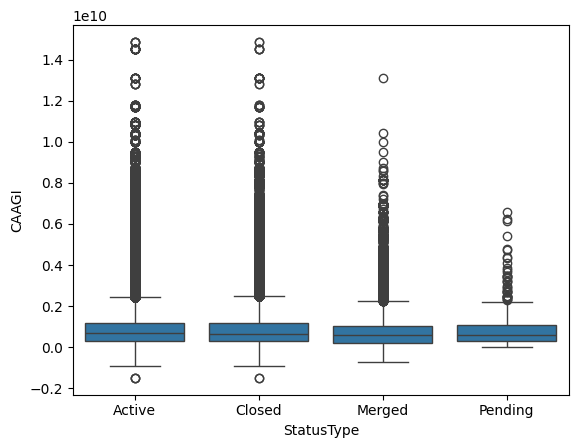

In [691]:
#Checking if Zip has anything to do with income.
sns.boxplot(data = income_school, x='StatusType', y= 'CAAGI')

In [692]:
''' 
THIS IS SHOWING THAT ACTIVE SCHOOLS TYPICALLY HAVE PEOPLE WITH HIGHER CAAGI(GROSS INCOME), WHILE PENDING SCHOOLS TYPICALLY HAVE A LOWER INCOME VALUE WHICH MAKES SENSE. UNDERSTANDING OF THE MERGED DATASET WILL NOW GO INTO PART 3
'''

' \nTHIS IS SHOWING THAT ACTIVE SCHOOLS TYPICALLY HAVE PEOPLE WITH HIGHER CAAGI(GROSS INCOME), WHILE PENDING SCHOOLS TYPICALLY HAVE A LOWER INCOME VALUE WHICH MAKES SENSE. UNDERSTANDING OF THE MERGED DATASET WILL NOW GO INTO PART 3\n'

PHASE 3:
    Modeling & Evaluation

Train a regression model using only the base dataset (baseline model)

Train the same model using the integrated dataset

Compare performance using appropriate metrics (e.g., RMSE, R²)

In [693]:
housing1['Zip'] = housing1['Zip'].astype(str).replace('.0', '').str[:5]
housing1 = housing1.merge(income_school, on='Zip', how='left')
housing1

,SALE TYPE,PROPERTY TYPE,ADDRESS,CITY,STATE OR PROVINCE,Zip,PRICE,BEDS,BATHS,LOCATION,...,City_y,County_y,Returns,CAAGI,TotalTaxLiability,CountyLatitude,CountyLongitude,GeoCounty,GeoCity,GeoZipCode
0,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,6636.0,1.042167e+09,60635205.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
1,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,6647.0,1.042774e+09,62815816.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
2,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,6810.0,1.054020e+09,67557364.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
3,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,6947.0,8.779333e+08,57729596.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
4,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,7152.0,9.055895e+08,58235968.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318407,New Construction Home,Single Family Residential,15675 El Gato Ln,Los Gatos,CA,95032,4550000,4.0,3.0,Los Gatos,...,Los Gatos,Santa Clara,9675.0,9.040409e+08,53547894.0,37.234238,-121.731723,POINT (-121.7317226 37.23423826),POINT (-121.97927 37.22131),POINT (-121.96084 37.237015)
318408,New Construction Home,Single Family Residential,15675 El Gato Ln,Los Gatos,CA,95032,4550000,4.0,3.0,Los Gatos,...,Los Gatos,Santa Clara,9367.0,8.105287e+08,50451693.0,37.234238,-121.731723,POINT (-121.7317226 37.23423826),POINT (-121.97927 37.22131),POINT (-121.96084 37.237015)
318409,New Construction Home,Single Family Residential,15675 El Gato Ln,Los Gatos,CA,95032,4550000,4.0,3.0,Los Gatos,...,Los Gatos,Santa Clara,9252.0,6.570738e+08,36427078.0,37.234238,-121.731723,POINT (-121.7317226 37.23423826),POINT (-121.97927 37.22131),POINT (-121.96084 37.237015)
318410,New Construction Home,Single Family Residential,15675 El Gato Ln,Los Gatos,CA,95032,4550000,4.0,3.0,Los Gatos,...,Los Gatos,Santa Clara,9053.0,6.170517e+08,33364007.0,37.234238,-121.731723,POINT (-121.7317226 37.23423826),POINT (-121.97927 37.22131),POINT (-121.96084 37.237015)


In [694]:
def slope_int(x,y):
    num = np.sum((x-np.mean(x))*(y-np.mean(y))) #Calculates the Numerator 
    den = np.sum((x-np.mean(x))**2) # Calculates the denominatior
    slope = num/den #Gives slope
    inter = np.mean(y) - (slope * np.mean(x)) #gives intercept
    return slope, inter

slope, inter = slope_int(housing1['SQUARE FEET'], housing1['PRICE'])
slope, inter
#SLOPE, INTER = FORMATTING!

(np.float64(538.294408422879), np.float64(375971.965941309))

In [695]:
x = 700
374572.38992295205 + 615.8952836950573*x
#THIS FEELS LIKE IT HAS OVERRESTIMATED QUITE A BIT

805699.0885094921

0.8356459987459833


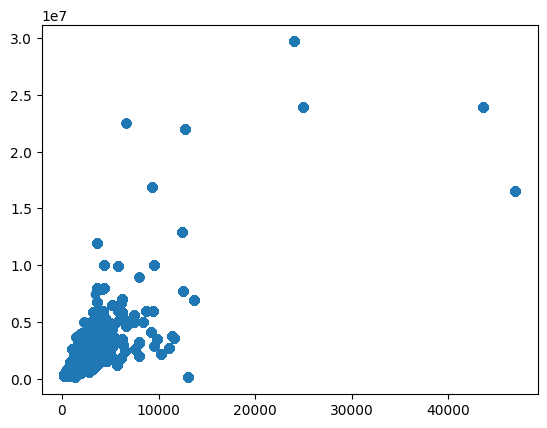

In [696]:
plt.scatter(housing1['SQUARE FEET'],housing1['PRICE']) 
correlation = housing1['SQUARE FEET'].corr(housing1['PRICE'])
print(correlation)
#THIS CORRELATION IS .76 THIS IS A VERY STRONG CORELLATION SHOWING THERE IS A DIRECT PRICE INCREASE AS THE SQUAREFOOTAGE INCREASES.

In [697]:
y_pred = inter + slope * housing1['SQUARE FEET'] #X IS SQUARE FT.
y_pred

0         7.581610e+05
1         7.581610e+05
2         7.581610e+05
3         7.581610e+05
4         7.581610e+05
              ...     
318407    1.977398e+06
318408    1.977398e+06
318409    1.977398e+06
318410    1.977398e+06
318411    1.977398e+06
Name: SQUARE FEET, Length: 318412, dtype: float64

In [698]:
def r_squared(y,y_pred):
    ssres = np.sum((y - y_pred)**2) #SSR values
    sstot = np.sum((y - np.mean(y))**2) #SST values
    return 1 - ssres/sstot

In [699]:
def mse(y, y_pred):
    return np.mean((y-y_pred)**2)

#MAE
def mae(y,y_pred):
    return np.mean(np.abs(y-y_pred)) #take the absolute value of y-y_pred.

In [700]:
print(r_squared(housing1['PRICE'], y_pred))
print(mse(housing1['PRICE'], y_pred))
print(mae(housing1['PRICE'], y_pred))

0.7081872975213508
1361710907687.3848
579319.1126359887


In [701]:
''' 
THIS R SQUARED IS FAIRLY DECENT IT CAN NOT GO PERFECT BUT IT IS PRETTY GOOD CONSIDERING WHICH WE EXPECT BECAUASE THEY HAVE SUCH A STRONG CORRELATION.
'''

' \nTHIS R SQUARED IS FAIRLY DECENT IT CAN NOT GO PERFECT BUT IT IS PRETTY GOOD CONSIDERING WHICH WE EXPECT BECAUASE THEY HAVE SUCH A STRONG CORRELATION.\n'

I WILL NOW ADD THE INCOME TO THE DATASET AND SEE IF THIS IMPROVES THE MODEL.

In [702]:
slope_sqrft, inter_sqrft = slope_int(housing1['SQUARE FEET'], housing1['PRICE'])
slope_inc, inter_inc = slope_int(housing1['CAAGI'], housing1['PRICE'])
#BREAKING WILL CHECK IF THERE IS NULL VALUES (WAS A MERGE ISSUE THAT I FIXED)

In [703]:
housing1['CAAGI'].isna().sum()

np.int64(5)

In [704]:
inter = np.mean(housing1['PRICE']) - (slope_sqrft * np.mean(housing1['SQUARE FEET']) + (slope_inc * np.mean(housing1['CAAGI'])))
inter

np.float64(100083.11170268431)

Text(0, 0.5, 'Actual')

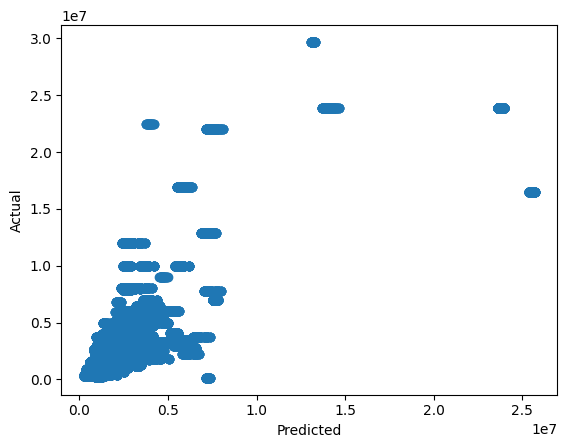

In [705]:

count = inter + slope_sqrft*housing1['SQUARE FEET'] + slope_inc*housing1['CAAGI']
count
plt.scatter(count, housing1['PRICE'])
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [706]:
slope, inter = slope_int(count, housing1['PRICE'])
slope, inter

(np.float64(0.9966122449796498), np.float64(10627.98830680456))

In [707]:
y_pred = inter + slope * count
y_pred

0         6.734696e+05
1         6.735756e+05
2         6.755418e+05
3         6.447564e+05
4         6.495915e+05
              ...     
318407    1.864427e+06
318408    1.848078e+06
318409    1.821250e+06
318410    1.814253e+06
318411    1.807076e+06
Length: 318412, dtype: float64

In [708]:
print(r_squared(housing1['PRICE'], y_pred))
print(mse(housing1['PRICE'], y_pred))
print(mae(housing1['PRICE'], y_pred))
#THIS MODEL IS NOW A LITTLE STRONGER about .012 BY ADDING INCOME INTO THIS. THIS WOULD LIKELY CONTINUE TO INCREASE THE ACCURACY IF I ADDED MORE FEATURES. IN THE PROJECT IT SAYS DO RMSE BUT I DO NOT KNOW HOW TO DO THAT. Instead I will try and add a 4th data point.

0.7180462261835301
1315723281330.7715
564554.729034138


In [709]:
city_mean = housing1.groupby("CITY")['PRICE'].mean()
city_mean

CITY
Bel Air                         1.250000e+05
Beverly Hills                   4.932421e+06
Canoga Park                     5.999990e+05
Chatsworth                      1.221400e+06
Culver City                     2.391176e+06
Daly City                       6.500000e+05
Encino                          2.786908e+06
Granada Hills                   1.571750e+06
Hollywood Hills East            2.099999e+06
Inglewood                       9.900000e+05
Lake Balboa                     9.474500e+05
Long Beach                      7.490000e+05
Los Angeles                     1.666380e+06
Los Gatos                       2.439536e+06
Marina Del Rey                  1.681400e+06
Mission Hills (san Fernando)    6.344995e+05
Monte Sereno                    5.728000e+06
North Hills                     8.234998e+05
North Hollywood                 1.228485e+06
Northridge                      1.874914e+06
Pacific Palisades               1.711000e+06
Pacoima                         7.399995e+05
Panor

In [713]:
city_avg = city_mean.to_frame() #makes it a dataframe 
city_avg

,PRICE
CITY,
Bel Air,1.250000e+05
Beverly Hills,4.932421e+06
Canoga Park,5.999990e+05
Chatsworth,1.221400e+06
Culver City,2.391176e+06
Daly City,6.500000e+05
Encino,2.786908e+06
Granada Hills,1.571750e+06
Hollywood Hills East,2.099999e+06


In [712]:
housing1

,SALE TYPE,PROPERTY TYPE,ADDRESS,CITY,STATE OR PROVINCE,Zip,PRICE,BEDS,BATHS,LOCATION,...,City_y,County_y,Returns,CAAGI,TotalTaxLiability,CountyLatitude,CountyLongitude,GeoCounty,GeoCity,GeoZipCode
0,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,6636.0,1.042167e+09,60635205.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
1,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,6647.0,1.042774e+09,62815816.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
2,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,6810.0,1.054020e+09,67557364.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
3,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,6947.0,8.779333e+08,57729596.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
4,MLS Listing,Condo/Co-op,7740 Redlands St Unit M2076,Playa Del Rey,CA,90293,495000,1.0,1.0,C31 - Playa Del Rey,...,Playa Del Rey,Los Angeles,7152.0,9.055895e+08,58235968.0,34.059483,-118.242048,POINT (-118.242048 34.0594833),POINT (-118.44799 33.95925),POINT (-118.4422707 33.9564526)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318407,New Construction Home,Single Family Residential,15675 El Gato Ln,Los Gatos,CA,95032,4550000,4.0,3.0,Los Gatos,...,Los Gatos,Santa Clara,9675.0,9.040409e+08,53547894.0,37.234238,-121.731723,POINT (-121.7317226 37.23423826),POINT (-121.97927 37.22131),POINT (-121.96084 37.237015)
318408,New Construction Home,Single Family Residential,15675 El Gato Ln,Los Gatos,CA,95032,4550000,4.0,3.0,Los Gatos,...,Los Gatos,Santa Clara,9367.0,8.105287e+08,50451693.0,37.234238,-121.731723,POINT (-121.7317226 37.23423826),POINT (-121.97927 37.22131),POINT (-121.96084 37.237015)
318409,New Construction Home,Single Family Residential,15675 El Gato Ln,Los Gatos,CA,95032,4550000,4.0,3.0,Los Gatos,...,Los Gatos,Santa Clara,9252.0,6.570738e+08,36427078.0,37.234238,-121.731723,POINT (-121.7317226 37.23423826),POINT (-121.97927 37.22131),POINT (-121.96084 37.237015)
318410,New Construction Home,Single Family Residential,15675 El Gato Ln,Los Gatos,CA,95032,4550000,4.0,3.0,Los Gatos,...,Los Gatos,Santa Clara,9053.0,6.170517e+08,33364007.0,37.234238,-121.731723,POINT (-121.7317226 37.23423826),POINT (-121.97927 37.22131),POINT (-121.96084 37.237015)


In [716]:
slope_sqrft, inter_sqrft = slope_int(housing1['SQUARE FEET'], housing1['PRICE'])
slope_inc, inter_inc = slope_int(housing1['CAAGI'], housing1['PRICE'])
slope_city, inter_city = slope_int(city_avg['PRICE'], housing1['PRICE'])
slope_city, inter_city


(np.float64(0.0), np.float64(1638367.7134121829))

In [ ]:
#WHAT THIS SLOPE TELLS US IS THAT THERE IS NO RELATION BETWEEN THE TWO VARIABLES. THIS IS LIKEY INCORRECT BUT I AM GOING OFF OF WHAT I WAS GIVEN.

4. Feature Analysis

Rank features by importance

Evaluate whether newly added features improve predictions

Discuss trade-offs (accuracy, complexity, interpretability)

In [ ]:
''' 
The Feautures that are the most important are the ones that I used. Squarefeet is by far the most important to the dataset and model. This allows for a direct correlation to the price of the house and is a fairly good predictor. A good secondary predictor though is income. This 
is because income has a direct correlation with what house you can afford and the price. The Data in the school data isnt as useful therefor I did not use it here because there is not many numerical driven points to hit in there. 

The features did add some improvement in terms of predictions but not enough for it to matter. This means that the trade off of accuracy is .012 and you can have a much simpler dataset and dataframe where it just predicts the price off of the square footage of the house. This makes 
much more sense because there is not a major tradeoff. It is also going to be easier to read when it is more simple. 
'''